In [ ]:
import pandas as pd
df = pd.read_csv('/content/alzheimers_reduced.csv')
print(df.head(), df['Diagnosis'].value_counts())

   Age  Gender  Ethnicity  EducationLevel       BMI  PhysicalActivity  \
0   86       0          2               1  0.065466          0.571099   
1   62       1          0               3  0.070065         -1.050032   
2   75       0          0               0 -0.316941          1.628134   
3   89       0          0               0 -0.567289         -1.257326   
4   76       1          0               2  1.533521          1.188813   

   FamilyHistoryAlzheimers  CardiovascularDisease  Diabetes  Depression  ...  \
0                        1                      0         0           0  ...   
1                        0                      0         0           0  ...   
2                        0                      1         1           1  ...   
3                        0                      0         0           0  ...   
4                        0                      0         1           0  ...   

   FunctionalAssessment  MemoryComplaints  BehavioralProblems       ADL  \
0    

In [ ]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

df.dropna(inplace=True)
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# CatBoost handles categorical features natively
# iterations = number of trees (like n_estimators in LightGBM)
# depth = tree depth, learning_rate controls step size
model = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, verbose=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['mild', 'moderate']))

              precision    recall  f1-score   support

        mild       0.94      0.94      0.94       241
    moderate       0.93      0.93      0.93       204

    accuracy                           0.93       445
   macro avg       0.93      0.93      0.93       445
weighted avg       0.93      0.93      0.93       445



In [ ]:
print(df['Diagnosis'].value_counts())

Diagnosis
0    1111
1    1111
Name: count, dtype: int64


In [ ]:
import joblib

joblib.dump(model, 'cognicare_catboost.pkl')
joblib.dump(le, 'label_encoder.pkl')

from google.colab import files
files.download('cognicare_catboost.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import time
from sklearn.metrics import classification_report , accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:{ accuracy * 100:.2f}%")


Accuracy:93.26%


In [ ]:
start_time = time.time()
y_pred = model.predict(X_test)
end_time = time.time()

response_time = end_time - start_time
print(f"Total Response Time: {response_time:.4f} seconds")
print(f"Avg Response Time per sample: {response_time / len(X_test) * 1000:.4f} ms")

Total Response Time: 0.0066 seconds
Avg Response Time per sample: 0.0148 ms


In [ ]:
print(classification_report(y_test, y_pred, target_names=['mild', 'moderate']))

              precision    recall  f1-score   support

        mild       0.94      0.94      0.94       241
    moderate       0.93      0.93      0.93       204

    accuracy                           0.93       445
   macro avg       0.93      0.93      0.93       445
weighted avg       0.93      0.93      0.93       445



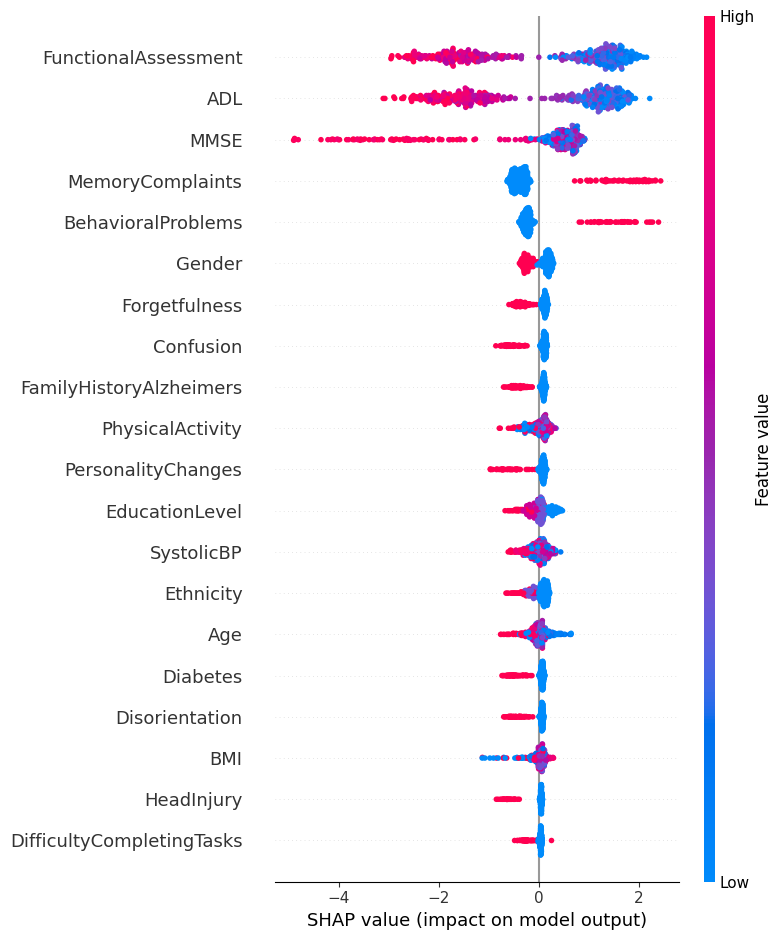

In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)